### Caso:

Hay una falta de conjuntos de datos públicos disponibles sobre servicios financieros y especialmente en el dominio emergente de transacciones de dinero móvil. Los conjuntos de datos financieros son importantes para muchos investigadores y, en particular, para nosotros que realizamos investigaciones en el ámbito de la detección de fraudes. Parte del problema es la naturaleza intrínsecamente privada de las transacciones financieras, que no lleva a conjuntos de datos disponibles públicamente.

Presentamos un conjunto de datos sintéticos generado utilizando el simulador llamado PaySim como un enfoque para tal problema. PaySim utiliza datos agregados del conjunto de datos privado para generar un conjunto de datos sintético que se asemeja al funcionamiento normal de las transacciones e inyecta un comportamiento malicioso para luego evaluar el rendimiento de los métodos de detección de fraude.

**dataset:** PS_20174392719_1491204439457_log.csv


### Información del atributo:

Variables de entrada (basadas en pruebas fisicoquímicas):

1. steep(tipo) - EFECTIVO, EFECTIVO, DÉBITO, PAGO y TRANSFERENCIA.

2. amount(cantidad) -monto de la transacción en moneda local.

3. nameOrig: cliente que inició la transacción

4. oldbalanceOrg - saldo inicial antes de la transacción

5. newbalanceOrig - nuevo saldo después de la transacción

6. nameDest - cliente que es el destinatario de la transacción

7. oldbalanceDest: destinatario del saldo inicial antes de la transacción. Tenga en cuenta que no hay información para los clientes que comienzan con M (Comerciantes).

8. newbalanceDest: nuevo destinatario del saldo después de la transacción. Tenga en cuenta que no hay información para los clientes que comienzan con M (Comerciantes).


9. isFlaggedFraud: el modelo de negocio tiene como objetivo controlar transferencias masivas de una cuenta a otra y señala intentos ilegales. Un intento ilegal en este conjunto de datos es un intento de transferir más de 200,000 en una sola transacción.

Variable de salida:

10. isFraud: son las transacciones realizadas por los agentes fraudulentos dentro de la simulación. En este conjunto de datos específico, el comportamiento fraudulento de los agentes apunta a obtener ganancias tomando el control de las cuentas de los clientes e intentando vaciar los fondos transfiriéndolos a otra cuenta y luego retirando del sistema.


### Actividades:

Nota: No considerar las siguientes variables 'step', 'nameOrig', 'nameDest', 'isFlaggedFraud' para el examen.

1.Dividir los datos para el entrenamiento y testeo en una proporción de 70 y 30, respectivamente. (2 pts.)
<br>
2.Aplicar balanceo de datos under-sampling, fijando como parámetro 0.8. (2 pts.)
<br>
3.Implementar el modelo de árboles de decisión a los datos de entrenamiento. (2 pts.)
<br>
4.Implementar el modelo de random forest a los datos de entrenamiento. (2 pts.)
<br>
5.Implementar el modelo de naive bayes a los datos de entrenamiento. (2 pts.)
<br>
6.Implementar el modelo de redes neuronales a los datos de entrenamiento. (2 pts.)
<br>
7.haciendo uso de las métricas de accuracy, sensibilidad. especificidad, auc y curva ROC evaluar los modelos generados (train y test) y realizar un análisis. (5 pts.)
<br>

Nota: considerar en códigos que requieran de semilla el valor de 2022.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#establecemos el directorio
import os
os.chdir("/home/david/clasesPython/avanzado/Examen/data") 

In [ ]:
df = pd.read_csv('PS_20174392719_1491204439457_log.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
df.corr()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
step,1.000000,0.022373,-0.010058,-0.010299,0.027665,0.025888,0.031578,0.003277
amount,0.022373,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688,0.012295
oldbalanceOrg,-0.010058,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154,0.003835
newbalanceOrig,-0.010299,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148,0.003776
oldbalanceDest,0.027665,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885,-0.000513
newbalanceDest,0.025888,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535,-0.000529
isFraud,0.031578,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000,0.044109
isFlaggedFraud,0.003277,0.012295,0.003835,0.003776,-0.000513,-0.000529,0.044109,1.000000


In [ ]:
from collections import Counter
Counter(df.isFraud)

Counter({0: 6354407, 1: 8213})

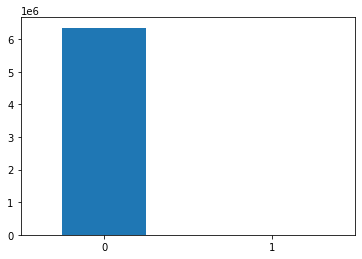

In [ ]:
value_counts = pd.value_counts(df['isFraud'],sort=True)
value_counts.plot(kind="bar",rot=0)
plt.show()

In [ ]:
pd.DataFrame(df['amount'],columns=['amount'])

,amount
0,9839.64
1,1864.28
2,181.00
3,181.00
4,11668.14
...,...
6362615,339682.13
6362616,6311409.28
6362617,6311409.28
6362618,850002.52


In [ ]:
a= df[df['amount']<92445516.64]
amount = pd.DataFrame(a,columns=['amount'])

In [ ]:
df['amount'].count()

6362620

# Limpieza de outliers

In [ ]:
def inferiorSuperior(data):    
    Q1= data.quantile(0.25)
    Q2_median= data.median()
    Q3= data.quantile(0.75)
    IQR= Q3-Q1
    bsup=(Q3 + 1.5*IQR)
    binf=(Q1 - 1.5 * IQR)
    return binf, bsup

## variable amount

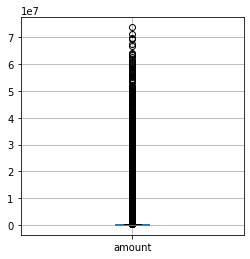

In [ ]:
plt.figure(figsize=(4,4))
amount.boxplot() #identifica todas las variables numéricas
plt.show()

In [ ]:
binf, bsup = inferiorSuperior(amount)

In [ ]:
filtrar= (df['amount']>=float(binf))&(df['amount']<=float(bsup))

In [ ]:
dfAmount = df[filtrar].reset_index()
dfAmount = dfAmount.drop(columns=['index'])
dfAmount

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6024537,742,CASH_OUT,258355.42,C1113162093,258355.42,0.00,C797688696,25176.67,283532.09,1,0
6024538,742,TRANSFER,63416.99,C778071008,63416.99,0.00,C1812552860,0.00,0.00,1,0
6024539,742,CASH_OUT,63416.99,C994950684,63416.99,0.00,C1662241365,276433.18,339850.17,1,0
6024540,743,TRANSFER,339682.13,C2013999242,339682.13,0.00,C1850423904,0.00,0.00,1,0


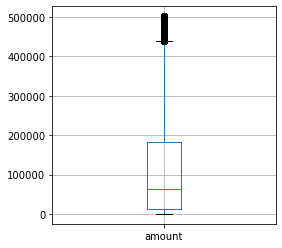

In [ ]:
amount = pd.DataFrame(dfAmount.amount,columns=['amount'])
plt.figure(figsize=(4,4))
amount.boxplot() #identifica todas las variables numéricas
plt.show()

In [ ]:
cantidadEliminados = 6362619-6024542
(100 * cantidadEliminados)/6362619  

5.313488046353239

### Eliminamos un 5 por ciento de nuestros datos por los outliers, vemos que no tuvimos algún problema por no ser muchos

## variable oldbalanceOrg

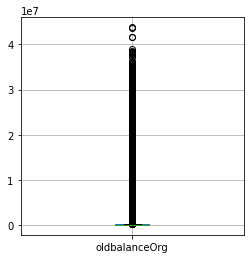

In [ ]:
oldBalance = pd.DataFrame(dfAmount['oldbalanceOrg'],columns=['oldbalanceOrg'])
plt.figure(figsize=(4,4))
oldBalance.boxplot() #identifica todas las variables numéricas
plt.show()

In [ ]:
binf, bsup = inferiorSuperior(oldBalance)

In [ ]:
sinoutOldBalance= (dfAmount['oldbalanceOrg']>=float(binf))&(dfAmount['oldbalanceOrg']<=float(bsup))


In [ ]:
sinoutOldBalance

0           True
1           True
2           True
3           True
4           True
           ...  
6024537     True
6024538     True
6024539     True
6024540    False
6024541    False
Name: oldbalanceOrg, Length: 6024542, dtype: bool

In [ ]:
dfAmountOldBalance = dfAmount[sinoutOldBalance]
dfAmountOldBalance

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6024533,742,CASH_OUT,54652.46,C43545501,54652.46,0.00,C830041824,0.00,54652.46,1,0
6024536,742,TRANSFER,258355.42,C1226129332,258355.42,0.00,C1744173808,0.00,0.00,1,0
6024537,742,CASH_OUT,258355.42,C1113162093,258355.42,0.00,C797688696,25176.67,283532.09,1,0
6024538,742,TRANSFER,63416.99,C778071008,63416.99,0.00,C1812552860,0.00,0.00,1,0


In [ ]:
dfAmountOldBalance= dfAmountOldBalance.dropna().reset_index()
dfAmountOldBalance = dfAmountOldBalance.drop(columns=['index'])
dfAmountOldBalance.isnull()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
4963374,False,False,False,False,False,False,False,False,False,False,False
4963375,False,False,False,False,False,False,False,False,False,False,False
4963376,False,False,False,False,False,False,False,False,False,False,False
4963377,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
print(dfAmount.count())
print(dfAmountOldBalance.count())
porcentajeE= (100*(dfAmount.count()-dfAmountOldBalance.count()))/dfAmount.count()
print('eliminamos el :',porcentajeE,'%')

step              6024542
type              6024542
amount            6024542
nameOrig          6024542
oldbalanceOrg     6024542
newbalanceOrig    6024542
nameDest          6024542
oldbalanceDest    6024542
newbalanceDest    6024542
isFraud           6024542
isFlaggedFraud    6024542
dtype: int64
step              4963379
type              4963379
amount            4963379
nameOrig          4963379
oldbalanceOrg     4963379
newbalanceOrig    4963379
nameDest          4963379
oldbalanceDest    4963379
newbalanceDest    4963379
isFraud           4963379
isFlaggedFraud    4963379
dtype: int64
eliminamos el : step              17.614003
type              17.614003
amount            17.614003
nameOrig          17.614003
oldbalanceOrg     17.614003
newbalanceOrig    17.614003
nameDest          17.614003
oldbalanceDest    17.614003
newbalanceDest    17.614003
isFraud           17.614003
isFlaggedFraud    17.614003
dtype: float64 %


### el 17 por ciento de nuestros datos eran outliers, podría ser perjudicial si se encuentra datos importantes

## Variable newbalanceOrig

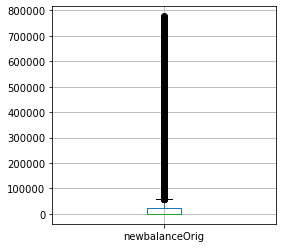

In [ ]:
newbalanceOrig = pd.DataFrame(dfAmountOldBalance['newbalanceOrig'],columns=['newbalanceOrig'])
plt.figure(figsize=(4,4)) 
newbalanceOrig.boxplot() #identifica todas las variables numéricas
plt.show()

In [ ]:
binf, bsup = inferiorSuperior(newbalanceOrig)

In [ ]:
sinoutnewBalance= (dfAmountOldBalance['newbalanceOrig']>=float(binf))&(dfAmountOldBalance['newbalanceOrig']<=float(bsup))

In [ ]:
dfAmountOldBalanceNewBalance = dfAmountOldBalance[sinoutnewBalance]
dfAmountOldBalanceNewBalance.isnull()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
4963374,False,False,False,False,False,False,False,False,False,False,False
4963375,False,False,False,False,False,False,False,False,False,False,False
4963376,False,False,False,False,False,False,False,False,False,False,False
4963377,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
dfAmountOldBalanceNewBalance= dfAmountOldBalanceNewBalance.dropna().reset_index()
dfAmountOldBalanceNewBalance = dfAmountOldBalanceNewBalance.drop(columns=['index'])
dfAmountOldBalanceNewBalance.isnull()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
4039713,False,False,False,False,False,False,False,False,False,False,False
4039714,False,False,False,False,False,False,False,False,False,False,False
4039715,False,False,False,False,False,False,False,False,False,False,False
4039716,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
print(dfAmountOldBalance.count())
print(dfAmountOldBalanceNewBalance.count())
porcentajeE= (100*(dfAmountOldBalance.count()-dfAmountOldBalanceNewBalance.count()))/dfAmountOldBalance.count()
print('eliminamos el :',porcentajeE,'%')

step              4963379
type              4963379
amount            4963379
nameOrig          4963379
oldbalanceOrg     4963379
newbalanceOrig    4963379
nameDest          4963379
oldbalanceDest    4963379
newbalanceDest    4963379
isFraud           4963379
isFlaggedFraud    4963379
dtype: int64
step              4039718
type              4039718
amount            4039718
nameOrig          4039718
oldbalanceOrg     4039718
newbalanceOrig    4039718
nameDest          4039718
oldbalanceDest    4039718
newbalanceDest    4039718
isFraud           4039718
isFlaggedFraud    4039718
dtype: int64
eliminamos el : step              18.60952
type              18.60952
amount            18.60952
nameOrig          18.60952
oldbalanceOrg     18.60952
newbalanceOrig    18.60952
nameDest          18.60952
oldbalanceDest    18.60952
newbalanceDest    18.60952
isFraud           18.60952
isFlaggedFraud    18.60952
dtype: float64 %


### Eliminamos solo un 3 por ciento del anterior data que teniamos, ya seria más del 20 por ciento eliminado

## Variable oldbalanceDest

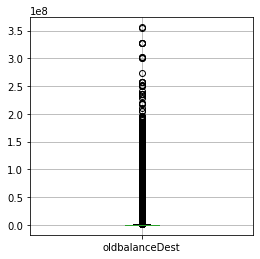

In [ ]:
oldbalanceDest = pd.DataFrame(dfAmountOldBalanceNewBalance['oldbalanceDest'],columns=['oldbalanceDest'])
plt.figure(figsize=(4,4))
oldbalanceDest.boxplot()  
plt.show()

In [ ]:
binf, bsup = inferiorSuperior(oldbalanceDest)

In [ ]:
sinoutoldBalanceDest= (dfAmountOldBalanceNewBalance['oldbalanceDest']>=float(binf))&(dfAmountOldBalanceNewBalance['oldbalanceDest']<=float(bsup))

In [ ]:
dfAmountnewoldBalanceoldDest = dfAmountOldBalanceNewBalance[sinoutoldBalanceDest]
dfAmountnewoldBalanceoldDest.isnull()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
4039713,False,False,False,False,False,False,False,False,False,False,False
4039714,False,False,False,False,False,False,False,False,False,False,False
4039715,False,False,False,False,False,False,False,False,False,False,False
4039716,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
dfAmountnewoldBalanceoldDest= dfAmountnewoldBalanceoldDest.dropna().reset_index()
dfAmountnewoldBalanceoldDest = dfAmountnewoldBalanceoldDest.drop(columns=['index'])
dfAmountnewoldBalanceoldDest.isnull()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
3504058,False,False,False,False,False,False,False,False,False,False,False
3504059,False,False,False,False,False,False,False,False,False,False,False
3504060,False,False,False,False,False,False,False,False,False,False,False
3504061,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
print(dfAmountOldBalanceNewBalance.count())
print(dfAmountnewoldBalanceoldDest.count())
porcentajeE= (100*(dfAmountOldBalanceNewBalance.count()-dfAmountnewoldBalanceoldDest.count()))/dfAmountOldBalanceNewBalance.count()
print('eliminamos el :',porcentajeE,'%')

step              4039718
type              4039718
amount            4039718
nameOrig          4039718
oldbalanceOrg     4039718
newbalanceOrig    4039718
nameDest          4039718
oldbalanceDest    4039718
newbalanceDest    4039718
isFraud           4039718
isFlaggedFraud    4039718
dtype: int64
step              3504063
type              3504063
amount            3504063
nameOrig          3504063
oldbalanceOrg     3504063
newbalanceOrig    3504063
nameDest          3504063
oldbalanceDest    3504063
newbalanceDest    3504063
isFraud           3504063
isFlaggedFraud    3504063
dtype: int64
eliminamos el : step              13.259713
type              13.259713
amount            13.259713
nameOrig          13.259713
oldbalanceOrg     13.259713
newbalanceOrig    13.259713
nameDest          13.259713
oldbalanceDest    13.259713
newbalanceDest    13.259713
isFraud           13.259713
isFlaggedFraud    13.259713
dtype: float64 %


### Los outliers están en un rango aceptable para eliminarlos sin preocupaciones, pero acumulados ya son más del 30 por ciento lo cual es preocupante

## Variable newbalanceDest

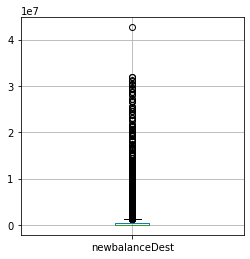

In [ ]:
newbalanceDest = pd.DataFrame(dfAmountnewoldBalanceoldDest['newbalanceDest'],columns=['newbalanceDest'])
plt.figure(figsize=(4,4))
newbalanceDest.boxplot() #identifica todas las variables numéricas
plt.show()

In [ ]:
binf, bsup = inferiorSuperior(newbalanceDest)

In [ ]:
sinoutnewBalanceDest= (dfAmountnewoldBalanceoldDest['newbalanceDest']>=float(binf))&(dfAmountnewoldBalanceoldDest['newbalanceDest']<=float(bsup))

In [ ]:
dfAmountnewoldBalanceonewoldDest = dfAmountnewoldBalanceoldDest[sinoutnewBalanceDest]
dfAmountnewoldBalanceonewoldDest.isnull()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
3504058,False,False,False,False,False,False,False,False,False,False,False
3504059,False,False,False,False,False,False,False,False,False,False,False
3504060,False,False,False,False,False,False,False,False,False,False,False
3504061,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
dfAmountnewoldBalanceonewoldDest= dfAmountnewoldBalanceonewoldDest.dropna().reset_index()
dfAmountnewoldBalanceonewoldDest = dfAmountnewoldBalanceonewoldDest.drop(columns=['index'])
dfAmountnewoldBalanceonewoldDest.isnull()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
3251404,False,False,False,False,False,False,False,False,False,False,False
3251405,False,False,False,False,False,False,False,False,False,False,False
3251406,False,False,False,False,False,False,False,False,False,False,False
3251407,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
print(dfAmountnewoldBalanceoldDest.count())
print(dfAmountnewoldBalanceonewoldDest.count())
porcentajeE= (100*(dfAmountnewoldBalanceoldDest.count()-dfAmountnewoldBalanceonewoldDest.count()))/dfAmountnewoldBalanceoldDest.count()
print('eliminamos el :',porcentajeE,'%')

step              3504063
type              3504063
amount            3504063
nameOrig          3504063
oldbalanceOrg     3504063
newbalanceOrig    3504063
nameDest          3504063
oldbalanceDest    3504063
newbalanceDest    3504063
isFraud           3504063
isFlaggedFraud    3504063
dtype: int64
step              3251409
type              3251409
amount            3251409
nameOrig          3251409
oldbalanceOrg     3251409
newbalanceOrig    3251409
nameDest          3251409
oldbalanceDest    3251409
newbalanceDest    3251409
isFraud           3251409
isFlaggedFraud    3251409
dtype: int64
eliminamos el : step              7.210316
type              7.210316
amount            7.210316
nameOrig          7.210316
oldbalanceOrg     7.210316
newbalanceOrig    7.210316
nameDest          7.210316
oldbalanceDest    7.210316
newbalanceDest    7.210316
isFraud           7.210316
isFlaggedFraud    7.210316
dtype: float64 %


In [ ]:
print(df.count())
print(dfAmountnewoldBalanceonewoldDest.count())
porcentajeE= (100*(df.count()-dfAmountnewoldBalanceonewoldDest.count()))/df.count()
print('eliminamos el :',porcentajeE,'%')

step              6362620
type              6362620
amount            6362620
nameOrig          6362620
oldbalanceOrg     6362620
newbalanceOrig    6362620
nameDest          6362620
oldbalanceDest    6362620
newbalanceDest    6362620
isFraud           6362620
isFlaggedFraud    6362620
dtype: int64
step              3251409
type              3251409
amount            3251409
nameOrig          3251409
oldbalanceOrg     3251409
newbalanceOrig    3251409
nameDest          3251409
oldbalanceDest    3251409
newbalanceDest    3251409
isFraud           3251409
isFlaggedFraud    3251409
dtype: int64
eliminamos el : step              48.898268
type              48.898268
amount            48.898268
nameOrig          48.898268
oldbalanceOrg     48.898268
newbalanceOrig    48.898268
nameDest          48.898268
oldbalanceDest    48.898268
newbalanceDest    48.898268
isFraud           48.898268
isFlaggedFraud    48.898268
dtype: float64 %


### Eliminamos un 48.89 por ciento de los datos con el proposito de escalar nuestros datos sin un sesgo, asi poder tener resultados más precisos. Nos preocupa que se haya eliminado datos importantes, pero por lo contrario la cantidad es suficiente para converger nuestros modelos.

## Dividimos nuestro dataset en las variables que nos interesan

In [ ]:
x = dfAmountnewoldBalanceonewoldDest.loc[:,['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']]
y = dfAmountnewoldBalanceonewoldDest['isFraud']

In [ ]:
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()

mm_data = mm.fit_transform(x)


In [ ]:
mm_data[50:]

array([[0.01283744, 0.00772996, 0.        , 0.        , 0.        ],
       [0.00978665, 0.14652717, 0.60643745, 0.        , 0.        ],
       [0.01284513, 0.0423843 , 0.09226041, 0.        , 0.        ],
       ...,
       [0.51494108, 0.91107528, 0.        , 0.01446349, 0.22397321],
       [0.12639957, 0.22363631, 0.        , 0.        , 0.        ],
       [0.12639957, 0.22363631, 0.        , 0.15880534, 0.26846109]])

In [ ]:
dfNuevo = pd.DataFrame(mm_data, columns=['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest'])

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(dfNuevo, y, test_size=0.30, random_state=42)

In [ ]:
from imblearn.under_sampling import NearMiss

In [ ]:
unds = NearMiss(sampling_strategy=0.8, 
                n_neighbors=100, 
                version=3) # semilla
x_t_unds, y_t_unds= unds.fit_resample(x_train,y_train) 

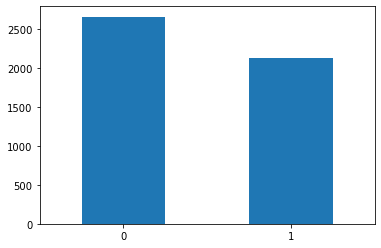

In [ ]:
value_counts = pd.value_counts(y_t_unds,sort=True)
value_counts.plot(kind="bar",rot=0)
plt.show()

In [ ]:
import tensorflow as tf

In [ ]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Input(shape=(1,)),
  tf.keras.layers.Dense(1)
])


In [ ]:
model.weights[0][0][0]

In [ ]:
opt=tf.keras.optimizers.SGD(
    learning_rate=0.0000001
)
model.compile(optimizer=opt,
              loss='mean_squared_error',
              metrics=['mean_squared_error'])

In [ ]:
model

In [ ]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Input(shape=(5,)),
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(256, activation='relu'),
  tf.keras.layers.Dense(2, activation='softmax')
])

In [ ]:
model.summary()

In [ ]:
model.weights[1]

In [ ]:
opt = tf.keras.optimizers.Adam(learning_rate=0.001)

# Compilamos el modelo
model.compile(optimizer=opt,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
hist = model.fit(x_t_unds, y_t_unds, validation_data=(x_test, y_test), epochs=2)

In [ ]:
resultado = pd.DataFrame(model.predict(x_t_unds), columns=['0','1'])


In [ ]:
resultado

In [ ]:
model.weights

In [ ]:
dfR=np.where(resultado['0']>resultado['1'],0,1)

In [ ]:
from sklearn import metrics
metrics.accuracy_score(y_t_unds,dfR) ##antes con 2 capas 1 64 2 128 0.6901878914405011

NameError: name 'dfR' is not defined

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
wqp_dt = DecisionTreeClassifier(criterion='entropy', #métrica de impureza
                                min_samples_split=400, #mínimo número de observaciones en el nodo
                                max_depth = 4, #profundidad máxima del árbol
                                random_state=99) #semilla


In [ ]:
wqp_dt.fit(x_t_unds, y_t_unds) #valores del target

DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_split=400,
                       random_state=99)

In [ ]:
wqp_dt_predictions = wqp_dt.predict(x_test) #predict()

In [ ]:

metrics.accuracy_score(y_test,wqp_dt_predictions)

0.9935299864776614

In [ ]:
train = wqp_dt.predict(x_t_unds) #predict()

metrics.accuracy_score(y_t_unds,train)

0.7058455114822547

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
wqp_rf = RandomForestClassifier(random_state=0)#este objeto es de tipo función
wqp_rf.fit(x_t_unds, y_t_unds)

RandomForestClassifier(random_state=0)

In [ ]:
wqp_rf_predictions = wqp_rf.predict(x_test) 


In [ ]:
metrics.accuracy_score(y_test,wqp_rf_predictions)

0.9915082994762272

In [ ]:
train = wqp_rf.predict(x_t_unds) #predict()

metrics.accuracy_score(y_t_unds,train)

0.9991649269311065

# Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
clf = GaussianNB()
clf.fit(x_t_unds, y_t_unds)

GaussianNB()

In [ ]:
yGaussian = clf.predict(x_t_unds)


In [ ]:
metrics.accuracy_score(y_t_unds,yGaussian)

0.5144050104384134